# >>> This notebook defines the models and generates the headers needed for the C program, containing model parameters and test samples. also has code blocks for generating plots

In [1]:
import numpy as np
import scipy.io as scio
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data, data_X, data_y = [],[],[]
file_path = "path to 6 TE models"

for mode in ['1','2','3','4','5','6']:
    mode_name = 'm' + mode + 'd00'
    temp = scio.loadmat(file_path + mode_name)[mode_name]
    data_X.append(temp[:,[0, 1, 2, 3, 4, 5, 8, 9, 10, 12, 13, 15, 17, 18, 20, 21]].copy())
    data_y.append(temp[:,32].copy())  #purge E

# np.round(pd.DataFrame(data_X[1]),3).head()


In [17]:
from sklearn.model_selection import train_test_split

In [7]:
X_trainvalid, X_test, y_trainvalid, y_test = train_test_split(data_X[0], data_y[0], test_size=.25, random_state = 77)
X_train, X_valid, y_train, y_valid = train_test_split(X_trainvalid, y_trainvalid, test_size=.14, random_state = 77)
X_train.shape, X_valid.shape, X_test.shape

((4643, 16), (757, 16), (1801, 16))

In [4]:
from importlib import reload
import my_Quantized_BLS_Regression_Quantized_and_Drift_Detector
reload(my_Quantized_BLS_Regression_Quantized_and_Drift_Detector)
from my_Quantized_BLS_Regression_Quantized_and_Drift_Detector import BLS_regression
from my_Quantized_BLS_Regression_Quantized_and_Drift_Detector import compute_quant_params

===================================================================================

# 1) Making the 30 long 8bit uint signatures for models

In [ ]:
# --- 1. Identify Global Range for Monitored Feature ---
MONITOR_IDX = 8 # Example: We monitor the 1st feature. Adjust as needed.
N_SAMPLES_KS = 30 
KS_LIMIT = 11 # Calculated threshold for N=30, alpha=0.05
TRAIN_IDX = 3000

# Stack all feature data for the monitored feature across all modes
# ASSUMPTION: You have X_M0, X_M1, ..., X_M5 loaded.
all_monitored_data = np.concatenate([
    data_X[0][:TRAIN_IDX, MONITOR_IDX],
    data_X[1][:TRAIN_IDX, MONITOR_IDX],
    data_X[2][:TRAIN_IDX, MONITOR_IDX],
    data_X[3][:TRAIN_IDX, MONITOR_IDX],
    data_X[4][:TRAIN_IDX, MONITOR_IDX],
    data_X[5][:TRAIN_IDX, MONITOR_IDX]
])

# Find the absolute min/max across all modes
global_min_ks = np.min(all_monitored_data)
global_max_ks = np.max(all_monitored_data)

# --- 2. Calculate Global KS Quantization Map ---
# Use your existing compute_quant_params, but enforce unsigned (0-255)
S_KS_Global, Zp_KS_Global = compute_quant_params(
    global_min_ks, 
    global_max_ks, 
    signed=False, 
    n_bits=8
)

# --- 3. Generate 6 Pre-Sorted Reference Buffers ---
reference_buffers = []
for idx in range(6): # Loop through all mode datasets
    raw_data = data_X[idx][:N_SAMPLES_KS, MONITOR_IDX] # Take first N_SAMPLES_KS
    # Quantize using the GLOBAL map
    quantized_data = np.round(raw_data / S_KS_Global + Zp_KS_Global).astype(np.uint8)
    # PRE-SORT the reference buffer for the C code
    sorted_reference = np.sort(quantized_data) 
    reference_buffers.append(sorted_reference)

# Now you have S_KS_Global, Zp_KS_Global, and reference_buffers to export

## > Signatures before quantization

In [6]:
[np.sort(data_X[0][:N_SAMPLES_KS, MONITOR_IDX].astype(np.float32)), 
 np.sort(data_X[1][:N_SAMPLES_KS, MONITOR_IDX].astype(np.float32)), 
 np.sort(data_X[2][:N_SAMPLES_KS, MONITOR_IDX].astype(np.float32)), 
 np.sort(data_X[3][:N_SAMPLES_KS, MONITOR_IDX].astype(np.float32)), 
 np.sort(data_X[4][:N_SAMPLES_KS, MONITOR_IDX].astype(np.float32)), 
 np.sort(data_X[5][:N_SAMPLES_KS, MONITOR_IDX].astype(np.float32))]

[array([91.935844, 91.935875, 91.9376  , 91.943054, 91.94679 , 91.95519 ,
        91.957016, 91.95732 , 91.96048 , 91.969894, 91.97409 , 91.97528 ,
        91.975555, 91.98326 , 91.98681 , 91.99327 , 91.99405 , 91.998245,
        91.99853 , 92.0059  , 92.00749 , 92.01652 , 92.017075, 92.028305,
        92.029976, 92.03031 , 92.03817 , 92.04203 , 92.053665, 92.07391 ],
       dtype=float32),
 array([90.134415, 90.14603 , 90.15882 , 90.17957 , 90.19322 , 90.21207 ,
        90.21566 , 90.22    , 90.22883 , 90.236374, 90.23669 , 90.24524 ,
        90.24717 , 90.24863 , 90.252235, 90.26288 , 90.263245, 90.26368 ,
        90.26575 , 90.27016 , 90.284096, 90.290665, 90.300064, 90.30379 ,
        90.30575 , 90.31496 , 90.32937 , 90.333435, 90.36315 , 90.37266 ],
       dtype=float32),
 array([83.44991 , 83.45406 , 83.455215, 83.46598 , 83.47309 , 83.47673 ,
        83.47722 , 83.47995 , 83.48409 , 83.48463 , 83.48629 , 83.48707 ,
        83.48775 , 83.48904 , 83.48915 , 83.48957 , 83.49194 , 8

## > Signatures after quantization

In [8]:
reference_buffers

[array([250, 250, 250, 250, 250, 251, 251, 251, 251, 251, 251, 251, 251,
        251, 251, 251, 251, 251, 251, 251, 251, 251, 251, 252, 252, 252,
        252, 252, 252, 252], dtype=uint8),
 array([225, 226, 226, 226, 226, 226, 227, 227, 227, 227, 227, 227, 227,
        227, 227, 227, 227, 227, 227, 227, 227, 228, 228, 228, 228, 228,
        228, 228, 229, 229], dtype=uint8),
 array([133, 133, 133, 133, 133, 133, 133, 133, 133, 133, 133, 133, 133,
        133, 133, 133, 133, 134, 134, 134, 134, 134, 134, 134, 134, 134,
        134, 134, 134, 134], dtype=uint8),
 array([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        5, 5, 5, 5, 5, 5, 6, 6], dtype=uint8),
 array([205, 206, 206, 206, 206, 206, 206, 206, 206, 206, 206, 206, 206,
        206, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207], dtype=uint8),
 array([ 98,  98,  98,  98,  99,  99,  99,  99,  99,  99,  99,  99,  99,
         99,  99,  99,  99,  99,  99,  99,  99,  9

# 2) Building the models (6 Models for 6 modes of TE)

In [ ]:
# --- Python Execution Script Outline ---
# 1. Base Model Initialization and Training (M0)

base_model = BLS_regression(
    lambd=0.1, shrink=1, n_features=10, n_ftr_groups=8, 
    n_enhancements=6, n_enh_groups=3, activation='relu6'
) 

indices = np.random.permutation(TRAIN_IDX)
# Train the base model (Mode 0)
base_model.fit(data_X[0][indices, :], data_y[0][indices], QAT=True, per_tensor_quant=True) 

# --- 2. Extract SHARED/FROZEN Constants (from M0) ---
shared_We = base_model.We
shared_Wh = base_model.Wh
shared_S_We = base_model.S_We
shared_Zp_We = base_model.Zp_We
shared_S_Wh = base_model.S_Wh
shared_Zp_Wh = base_model.Zp_Wh

# --- 3. Generate Global KS Quantization and Reference Buffers ---
# (You must perform this step by analyzing the range of the monitored feature across ALL data)

#done in previous code block

# --- 4. Fine-Tune and Extract MODE-SPECIFIC CONFIGS (M0 to M5) ---
print(f'Model 0 (base) Fit_RMSE: {base_model.fit_RMSE}\t Fit_MAPE: {base_model.fit_MAPE*100:.3f}%')

all_mode_configs = []
for i in range(6):
    # Clone the Base Model's frozen weights for fine-tuning
    current_model = BLS_regression(0.1, 1, 10, 8, 6, 3) # Initialize with same hyperparameters
    current_model.We = shared_We
    current_model.Wh = shared_Wh
    current_model.S_We = shared_S_We
    current_model.Zp_We = shared_Zp_We
    current_model.S_Wh = shared_S_Wh
    current_model.Zp_Wh = shared_Zp_Wh
    
    # Run the corrected fit_transfer (M0 is effectively re-run here for consistency)
    current_model.fit_transfer(data_X[i][indices, :], data_y[i][indices], QAT=True, per_tensor_quant=True) 
    if i != 0: print(f'Model {i}\tFit_RMSE: {current_model.fit_RMSE}\t Fit_MAPE: {current_model.fit_MAPE*100:.3f}%')
    # current_model.predict(test_scenario_1_drift_X, test_scenario_1_drift_y, PTQ=True)
    # print(f'Model {i}\tpred_RMSE: {current_model.pred_RMSE}\t pred_MAPE: {current_model.pred_MAPE*100:.3f}%\n')

    # Export the final configuration for this mode
    config = current_model.export_mode_config(
        monitored_feature_idx=MONITOR_IDX, 
        reference_buffer=reference_buffers[i],
        ks_limit=KS_LIMIT
    )
    all_mode_configs.append(config)
    
# --- 5. Final Step: Write C Header Files ---
# (This step converts the Python objects into C arrays/structs)
# ... write script to generate bls_shared_weights.h and bls_mode_configs.h

Model 0 (base) Fit_RMSE: 0.25505892529060975	 Fit_MAPE: 1.289%
Model 1	Fit_RMSE: 0.41491861586804096	 Fit_MAPE: 1.481%
Model 2	Fit_RMSE: 0.24321828199861745	 Fit_MAPE: 4.833%
Model 3	Fit_RMSE: 0.3048990029831464	 Fit_MAPE: 1.577%
Model 4	Fit_RMSE: 0.40027837708389535	 Fit_MAPE: 1.397%
Model 5	Fit_RMSE: 0.26459956832738957	 Fit_MAPE: 5.209%


# 3) Storring the shared parameters (We, Wh and their quantization parameters)

In [15]:
# --- 1. Quantize the Frozen We and Wh Weights ---

# We/S_We/Zp_We are lists of arrays (one element per feature group)
We_quant_list = []
for We_i, S_We_i, Zp_We_i in zip(shared_We, shared_S_We, shared_Zp_We):
    # Quantize We_i using its specific S/Zp
    quantized = np.round(We_i / S_We_i + Zp_We_i).astype(np.uint8)
    We_quant_list.append(quantized.flatten()) # Flatten each group

# Wh/S_Wh/Zp_Wh are lists of arrays (one element per enhancement group)
Wh_quant_list = []
for Wh_j, S_Wh_j, Zp_Wh_j in zip(shared_Wh, shared_S_Wh, shared_Zp_Wh):
    # Quantize Wh_j using its specific S/Zp
    quantized = np.round(Wh_j / S_Wh_j + Zp_Wh_j).astype(np.uint8)
    Wh_quant_list.append(quantized.flatten()) # Flatten each group

# Combine all groups into a single 1D numpy array for C export
We_quant_flat = np.concatenate(We_quant_list)
Wh_quant_flat = np.concatenate(Wh_quant_list)

# --- 2. Create the shared_params Dictionary ---
shared_params = {
    'We_quant': We_quant_flat,
    'Wh_quant': Wh_quant_flat,
    
    # S/Zp arrays also need to be concatenated/flattened for C export
    'S_We': np.concatenate(shared_S_We),
    'Zp_We': np.concatenate(shared_Zp_We),
    'S_Wh': np.concatenate(shared_S_Wh),
    'Zp_Wh': np.concatenate(shared_Zp_Wh),
}

# 4) Generating C header files (for shared parameters and mode-specific parameters)

In [ ]:
import numpy as np

# --- C CODE GENERATION UTILITIES ---

def format_c_array(arr, name, dtype="float", const_qualifier="const"):
    """Converts a 1D or flattened numpy array into a C array declaration string."""
    
    # 1. Determine C Data Type
    c_dtype = {
        "float": "float", 
        "uint8": "uint8_t", 
        "int32": "int32_t"
    }.get(dtype, dtype)
    
    # 2. Format Array Elements
    flat_arr = arr.flatten()
    
    if dtype == "float":
        # Format floats with 'f' suffix for C float literal
        elements = [f"{x:.8f}f" for x in flat_arr]
    else:
        # Format integers
        elements = [f"{int(x)}" for x in flat_arr]

    # 3. Format Array into Lines (10 elements per line for readability)
    lines = []
    for i in range(0, len(elements), 10):
        lines.append("    " + ", ".join(elements[i:i+10]))
    
    elements_str = ",\n".join(lines)
    
    return f"{const_qualifier} {c_dtype} {name}[{len(flat_arr)}] = {{\n{elements_str}\n}};"


def write_c_headers(shared_params, all_mode_configs, S_KS_Global, Zp_KS_Global, MONITOR_IDX, KS_LIMIT, N_MODES=6):
    """Generates the bls_shared_weights.h and bls_mode_configs.h files."""
    
    # --- 1. Generate bls_shared_weights.h ---
    
    # Flatten We and Wh (quantized) for C, as they are large
    We_quant = shared_params['We_quant'].flatten()
    Wh_quant = shared_params['Wh_quant'].flatten()
    
    shared_header = [
        "// AUTO-GENERATED FILE. SHARED/FROZEN CONSTANTS",
        "#ifndef BLS_SHARED_WEIGHTS_H",
        "#define BLS_SHARED_WEIGHTS_H",
        "#include <stdint.h>\n",
        f"// We_quant Shape: {shared_params['We_quant'].shape}",
        format_c_array(We_quant, "We_quant", "uint8"),
        f"// Wh_quant Shape: {shared_params['Wh_quant'].shape}",
        format_c_array(Wh_quant, "Wh_quant", "uint8"),
        
        "\n// --- Shared Quantization Parameters ---",
        format_c_array(shared_params['S_We'], "S_We", "float"),
        format_c_array(shared_params['Zp_We'], "Zp_We", "uint8"),
        format_c_array(shared_params['S_Wh'], "S_Wh", "float"),
        format_c_array(shared_params['Zp_Wh'], "Zp_Wh", "uint8"),

        "\n#endif // BLS_SHARED_WEIGHTS_H"
    ]
    
    # Replace the existing placeholder with the actual file path you want
    with open("bls_shared_weights.h", "w") as f:
        f.write('\n'.join(shared_header))


    # --- 2. Generate bls_mode_configs.h (containing the ModeConfig_t struct definition) ---
    
    mode_config_header = [
        "// AUTO-GENERATED FILE. MODE-SPECIFIC CONSTANTS AND REGISTRY",
        "#ifndef BLS_MODE_CONFIGS_H",
        "#define BLS_MODE_CONFIGS_H",
        "#include <stdint.h>",
        "#include <stdbool.h>",
        
        "\n// --- STRUCT DEFINITION (Needs to be defined in main.h or a common header) ---",
        "// We will define it here for completeness, assuming you copy it to main.h or a shared file later.",
        "typedef struct {",
        "    const float* scaler_mean;  const float* scaler_std;",
        "    const float* clip_min;     const float* clip_max;",
        "    const float* S_X;          const uint8_t* Zp_X;",
        "    const float* win_mean;     const float* win_dist;",
        "    const float* S_Zn;         const uint8_t* Zp_Zn;",
        "    const float* S_Hn;         const uint8_t* Zp_Hn;",
        "    const float* S_Wn;         const uint8_t* Zp_Wn;",
        "    const uint8_t* Wn_quant;",
        "    const uint8_t* Reference_Buffer; // Pre-sorted uint8_t array for KS test",
        "} ModeConfig_t;\n"
    ]
    
    # Global KS Detector Constants (Fixed for all modes)
    mode_config_header.append("// --- Global Drift Detector Constants ---")
    # S_KS_Global and Zp_KS_Global are likely 1-element arrays, so we index [0]
    mode_config_header.append(f"const float S_KS_Global = {S_KS_Global:.8f}f;")
    mode_config_header.append(f"const uint8_t Zp_KS_Global = {Zp_KS_Global};")
    mode_config_header.append(f"#define MONITORED_FEATURE_IDX {MONITOR_IDX}")
    mode_config_header.append(f"#define KS_LIMIT {KS_LIMIT}\n")

    # Mode-Specific Constant Arrays (Write the data blocks first)
    config_registry_entries = []
    for i, config in enumerate(all_mode_configs):
        prefix = f"M{i}_"
        mode_config_header.append(f"// --- MODE {i} CONSTANTS ---")
        
        # Write all arrays
        for key in config:
            if key not in ["Monitored_Feature_Idx", "KS_Limit"]: # Skip the globals
                dtype = "uint8" if "Zp" in key or "quant" in key or "Buffer" in key else "float"
                mode_config_header.append(format_c_array(config[key], f"{prefix}{key}", dtype))

        # Create the registry entry (Pointer references)
        registry_entry = (
            f"    {{\n"
            f"        .scaler_mean = {prefix}scaler_mean, .scaler_std = {prefix}scaler_std,\n"
            f"        .clip_min = {prefix}clip_min, .clip_max = {prefix}clip_max,\n"
            f"        .S_X = {prefix}S_X, .Zp_X = {prefix}Zp_X,\n"
            f"        .win_mean = {prefix}win_mean, .win_dist = {prefix}win_dist,\n"
            f"        .S_Zn = {prefix}S_Zn, .Zp_Zn = {prefix}Zp_Zn,\n"
            f"        .S_Hn = {prefix}S_Hn, .Zp_Hn = {prefix}Zp_Hn,\n"
            f"        .S_Wn = {prefix}S_Wn, .Zp_Wn = {prefix}Zp_Wn,\n"
            f"        .Wn_quant = {prefix}Wn_quant,\n"
            f"        .Reference_Buffer = {prefix}Reference_Buffer,\n"
            f"    }}"
        )
        config_registry_entries.append(registry_entry)

    # 3. Mode Registry Array
    mode_config_header.append("\n/* --- Global Mode Configuration Registry (Pointers) --- */")
    mode_config_header.append(f"const ModeConfig_t Modes[{N_MODES}] = {{")
    mode_config_header.append(",\n".join(config_registry_entries))
    mode_config_header.append("};")

    mode_config_header.append("\n#endif // BLS_MODE_CONFIGS_H")
    
    # Replace the existing placeholder with the actual file path you want
    with open("bls_mode_configs.h", "w") as f:
        f.write('\n'.join(mode_config_header))
        
    print("\n--- C Header Files Generated ---")
    print("1. bls_shared_weights.h (Frozen We/Wh and their S/Zp)")
    print("2. bls_mode_configs.h (All mode-specific parameters and KS globals)")


In [ ]:
write_c_headers(
    shared_params,          # <-- defined in code block 3
    all_mode_configs,       # Generated in your loop (M0 to M5)
    S_KS_Global,            # Global KS scale
    Zp_KS_Global,           # Global KS zero point
    MONITOR_IDX,            # Global feature index (e.g., 8)
    KS_LIMIT,               # Global integer threshold (e.g., 11)
    N_MODES=6
)


--- C Header Files Generated ---
1. bls_shared_weights.h (Frozen We/Wh and their S/Zp)
2. bls_mode_configs.h (All mode-specific parameters and KS globals)


========================================================================

# 5) Test file generator (as a header file for C)

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_valid, X_test = [], [], []
y_train, y_valid, y_test = [], [], []
for mode in range(6):
    X_trainvalid_temp, X_test_temp, y_trainvalid_temp, y_test_temp = train_test_split(data_X[mode], data_y[mode], test_size=.25, random_state = 77)
    X_train_temp, X_valid_temp, y_train_temp, y_valid_temp = train_test_split(X_trainvalid, y_trainvalid, test_size=.14, random_state = 77)
    X_train.append(X_train_temp)
    X_valid.append(X_valid_temp)
    X_test.append(X_test_temp)
    y_train.append(y_train_temp)
    y_valid.append(y_valid_temp)
    y_test.append(y_test_temp)
    
len(X_train), len(X_valid),len(X_test)

(6, 6, 6)

In [120]:
X_train[0].shape, X_valid[0].shape, X_test[0].shape

((4643, 16), (757, 16), (1801, 16))

## > 150 samples with drift

In [128]:
test_scenario_1_drift_X = np.concatenate([X_test[0][:70,], X_test[1][:80,]])
test_scenario_1_drift_y = np.concatenate([y_test[0][:70], y_test[1][:80]])
test_scenario_1_drift_X.shape, test_scenario_1_drift_y.shape

((150, 16), (150,))

In [ ]:
def write_c_header(filename, X, y_true):
    with open(filename, 'w') as f:
        f.write("// AUTO-GENERATED TEST BATCH\n")
        f.write(f"// Contains {len(X)} samples from Validation Set\n")
        f.write("#ifndef TEST_BATCH_DATA_H\n")
        f.write("#define TEST_BATCH_DATA_H\n\n")
        
        f.write(f"#define N_TEST_SAMPLES {len(X)}\n\n")
        
        # Write Inputs (2D Array)
        f.write(f"const float test_input_batch[{len(X)}][16] = {{\n")
        for i in range(len(X)):
            f.write("    {")
            for j in range(16):
                f.write(f"{X[i][j]:.6f}f, ")
            f.write("},\n")
        f.write("};\n\n")
        
        # Write True Targets (1D Array)
        f.write(f"const float test_target_batch[{len(X)}] = {{\n    ")
        for i, val in enumerate(y_true):
            # Handle 1D or 2D y array
            val_float = val[0] if isinstance(val, (list, np.ndarray)) else val
            f.write(f"{val_float:.6f}f, ")
            if (i+1) % 10 == 0: f.write("\n    ")
        f.write("\n};\n\n")

        f.write("#endif\n")
    print(f"Successfully generated {filename}")

In [129]:
write_c_header("test_scenario_1_drift.h", test_scenario_1_drift_X, test_scenario_1_drift_y)

Successfully generated test_scenario_1_drift.h


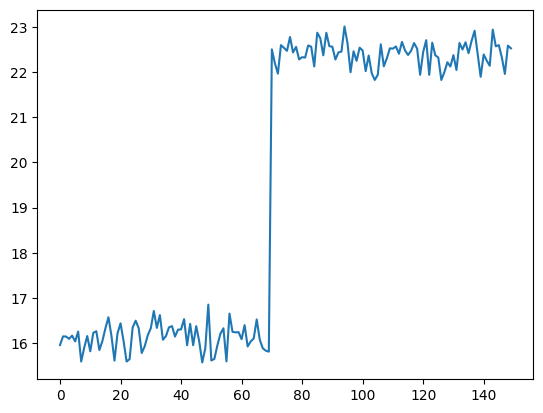

In [130]:
plt.plot(test_scenario_1_drift_y)

## > 100 samples for each mode (generates 6 files for 6 modes)

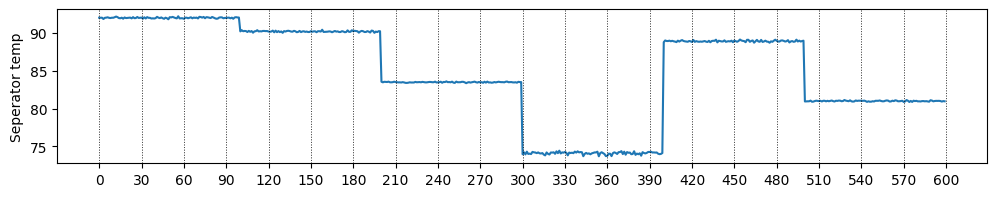

In [31]:
conc = []
for i in range(6):
    conc = np.concatenate([conc, X_test[i][:100,8]])


buffer_indices = np.arange(0, 601, 30)
plt.figure(figsize=(12,2))
plt.plot(conc)
plt.xticks(buffer_indices, buffer_indices)
plt.ylabel("Seperator temp")
for buffer_idx in buffer_indices:
    plt.axvline(x=buffer_idx, color='black', linestyle=':', linewidth=0.7, alpha=0.5)
    plt.axvline(x=buffer_idx, color='black', linestyle=':', linewidth=0.7, alpha=0.5)

In [36]:
for i in range(6):
    filename = f"test_mode{i}_100.h"
    write_c_header(filename, X_test[i][:100,], y_test[i][:100])

Successfully generated test_mode0_100.h
Successfully generated test_mode1_100.h
Successfully generated test_mode2_100.h
Successfully generated test_mode3_100.h
Successfully generated test_mode4_100.h
Successfully generated test_mode5_100.h


## > 100 samples for each mode (generates 1 file containing all 6 modes)

In [ ]:

with open("test_all_modes_100.h", 'w') as f:

    f.write("// AUTO-GENERATED TEST BATCH\n")
    f.write(f"// Contains {len(X)} samples from Validation Set\n")
    f.write("#ifndef TEST_BATCH_DATA_H\n")
    f.write("#define TEST_BATCH_DATA_H\n\n")
    
    f.write(f"#define N_TEST_SAMPLES {len(X)}\n\n")
    for k in range(6):
        X = X_test[k][:100,]
        y_true = y_test[k][:100]
        
        # Write Inputs (2D Array)
        f.write(f"const float test_mode{k}_input_batch[{len(X)}][16] = {{\n")
        for i in range(len(X)):
            f.write("    {")
            for j in range(16):
                f.write(f"{X[i][j]:.6f}f, ")
            f.write("},\n")
        f.write("};\n\n")
        
        # Write True Targets (1D Array)
        f.write(f"const float test_mode{k}_target_batch[{len(X)}] = {{\n    ")
        for i, val in enumerate(y_true):
            # Handle 1D or 2D y array
            val_float = val[0] if isinstance(val, (list, np.ndarray)) else val
            f.write(f"{val_float:.6f}f, ")
            if (i+1) % 10 == 0: f.write("\n    ")
        f.write("\n};\n\n")

    f.write("#endif\n")
print(f"Successfully generated test_all_modes_100.h")

Successfully generated test_mode5_100.h


# 6) Plotting log file

In [151]:
def analyze_drift_log_with_ground_truth(file_path, buffer_size=30):
    """
    Reads the BLS drift log CSV and plots the data, 
    showing the Active Model Index, the Ground Truth Mode, and Buffer Cycles.
    """
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: Log file not found at {file_path}")
        return

    # --- Setup the Plot ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, 
                                   gridspec_kw={'height_ratios': [3, 1]})
    
    # 1. Get points where the Data Set Mode changes (to separate batches)
    mode_change_indices = df[df['Data_Set_Mode'].diff() != 0].index.tolist()
    
    # 2. Get points where the Buffer is full (every 30 samples)
    buffer_indices = np.arange(buffer_size, df['Sample_Global'].max(), buffer_size)
    
    # --- Plot 1: Prediction vs. Target ---
    ax1.plot(df['Sample_Global'], df['Real_Target'], label='Real Target ($y$)', color='blue', linewidth=1.5)
    ax1.plot(df['Sample_Global'], df['Predicted_Value'], label='Predicted Value ($\\hat{y}$)', color='red', linestyle='--', linewidth=1)
    
    # Highlight high error samples
    high_error_threshold = df['Error_Abs'].quantile(0.95)
    high_error_samples = df[df['Error_Abs'] > high_error_threshold]
    ax1.scatter(high_error_samples['Sample_Global'], high_error_samples['Predicted_Value'], 
                color='orange', marker='o', s=20, label='High Error Samples')

    ax1.set_title('BLS Model Prediction vs. Ground Truth Over Time (Buffer Cycles Highlighted)', fontsize=14)
    ax1.set_ylabel('Value', fontsize=12)
    ax1.legend(loc='lower left')
    # ax1.grid(True, linestyle=':', alpha=0.6)
    
    # --- Plot 2: Active Model Index & Ground Truth ---
    
    # 🚨 Addition 1: Plot the Ground Truth Mode (Data_Set_Mode)
    ax2.plot(df['Sample_Global'], df['Data_Set_Mode'], drawstyle='steps-post', 
             label='Ground Truth Mode (Data Set)', color='purple', linestyle='-', linewidth=3, alpha=0.6)
    
    # 🚨 Addition 2: Plot the Chosen Model (Active_Model_Index)
    ax2.plot(df['Sample_Global'], df['Active_Model_Index'], drawstyle='steps-post', 
             label='Chosen Model (Drift Detector Output)', color='green', linewidth=2)
    
    mode_indices = df['Data_Set_Mode'].unique() # Use data set mode for y-axis range
    ax2.set_yticks(sorted(mode_indices))
    ax2.set_yticklabels([f'Mode {int(i)}' for i in sorted(mode_indices)])
    
    ax2.set_title('Model Tracking: Chosen Model vs. Ground Truth', fontsize=14)
    ax2.set_xlabel('Global Sample Index (Time)', fontsize=12)
    ax2.set_ylabel('Model Index', fontsize=12)
    ax2.legend(loc='lower right')
    ax2.grid(True, linestyle=':', alpha=0.6)
    
    # --- Add Vertical Lines to Both Plots ---
    
    # Add Buffer Cycle Lines (Dotted Black)
    for buffer_idx in buffer_indices:
        ax1.axvline(x=buffer_idx, color='black', linestyle=':', linewidth=0.7, alpha=0.5)
        ax2.axvline(x=buffer_idx, color='black', linestyle=':', linewidth=0.7, alpha=0.5)

    # Add Data Set Change Lines (Solid Gray)
    for mode_idx in mode_change_indices:
        ax1.axvline(x=mode_idx, color='gray', linestyle='-', linewidth=1.5, alpha=0.7)
        ax2.axvline(x=mode_idx, color='gray', linestyle='-', linewidth=1.5, alpha=0.7)
        
        current_data_mode = df.loc[mode_idx, 'Data_Set_Mode']
        if current_data_mode != 0:
             mode_text = f"Drift Starts (Data Set {current_data_mode})"
             ax1.text(mode_idx + 2, ax1.get_ylim()[1] * 0.95, mode_text, rotation=0, 
                      verticalalignment='top', fontsize=10, color='gray')


    # Final adjustments and saving
    plt.tight_layout()
    plot_filename = 'bls_drift_analysis_ground_truth.png'
    plt.savefig(plot_filename)
    plt.close()
    
    print(f"Analysis saved to {plot_filename}")

# Execute the function with the assumed buffer size of 30
analyze_drift_log_with_ground_truth('bls_drift_log.csv', buffer_size=30)

C:\Users\Asus\AppData\Local\Temp\ipykernel_17068\2908995087.py:77: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_17068\2908995087.py:77: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_17068\2908995087.py:77: UserWarning: Glyph 86 (V) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_17068\2908995087.py:77: UserWarning: Glyph 97 (a) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_17068\2908995087.py:77: UserWarning: Glyph 117 (u) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_17068\2908995087.py:77: UserWarning: Glyph 101 (e) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\Asus\AppData\Local\Temp\ipykernel_17068\2908995087.py:77: UserWarning: Glyph 66 (B) missing from font(s) B Naza

Analysis saved to bls_drift_analysis_ground_truth.png
